In [9]:
import SimDAT2D.SimDAT2D_MDK as sim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import IsoDAT2D.IsoDAT2D_MDK as iso
from PIL import Image
import pyFAI, fabio
from pyFAI.gui import jupyter
import pyFAI
import os
import matplotlib.pyplot as plt
from tifffile import imread
from SimDAT2D import masking
import pyFAI.azimuthalIntegrator as AI

In [12]:
# # to reload any iterative changes to the code, uncomment the following lines:
import importlib
sim = importlib.reload(sim)
iso = importlib.reload(iso)

Select calibrant:
1. AgBh
2. Al
3. alpha_Al2O3
4. Au
5. C14H30O
6. CeO2
7. Cr2O3
8. cristobaltite
9. CrOx
10. CuO
11. hydrocerussite
12. LaB6
13. LaB6_SRM660a
14. LaB6_SRM660b
15. LaB6_SRM660c
16. mock
17. NaCl
18. Ni
19. PBBA
20. Pt
21. quartz
22. Si
23. Si_SRM640
24. Si_SRM640a
25. Si_SRM640b
26. Si_SRM640c
27. Si_SRM640d
28. Si_SRM640e
29. TiO2
30. ZnO
Ni


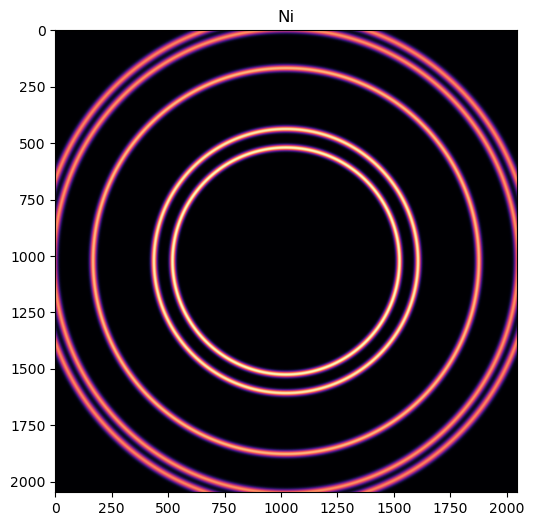

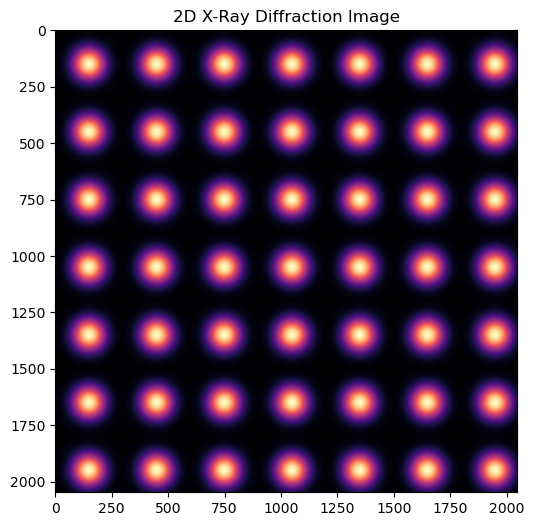

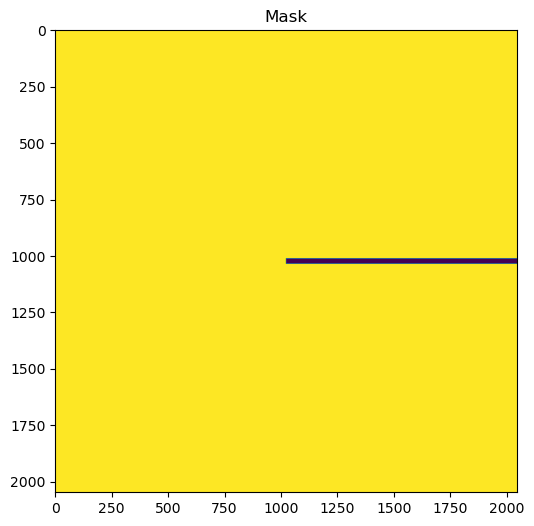

In [6]:
thin_film = sim.create_isotropic(.4, .5e-10, cmap = 'magma')
substrate = sim.create_anisotropic(25, 50, 300, 300, cmap = 'magma')
mask12 = sim.create_mask(thin_film, 12)

apply "label masks" pre-integration

[[4.46901263e-204 2.69339312e-203 1.54289701e-202 ... 1.58985450e-202
  2.79236201e-203 4.67838615e-204]
 [2.69334257e-203 1.54707543e-202 8.57488958e-202 ... 8.79592021e-202
  1.59378149e-202 2.79240825e-203]
 [1.54284930e-202 8.57477729e-202 4.63888719e-201 ... 4.74265728e-201
  8.79462398e-202 1.58960094e-202]
 ...
 [1.54106612e-202 8.56638382e-202 4.63494660e-201 ... 4.73871660e-201
  8.78623033e-202 1.58781773e-202]
 [2.68892999e-203 1.54499302e-202 8.56508761e-202 ... 8.78611803e-202
  1.59169903e-202 2.78799558e-203]
 [4.45967761e-204 2.68897623e-203 1.54081256e-202 ... 1.58777001e-202
  2.78794502e-203 4.66905093e-204]]
Label distribution: {'iso': 4194304}


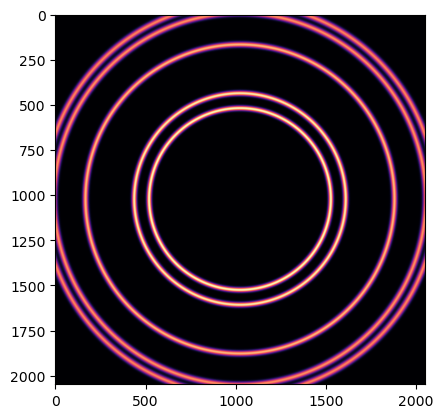

[[4.46901263e-204 2.69339312e-203 1.54289701e-202 ... 1.58985450e-202
  2.79236201e-203 4.67838615e-204]
 [2.69334257e-203 1.54707543e-202 8.57488958e-202 ... 8.79592021e-202
  1.59378149e-202 2.79240825e-203]
 [1.54284930e-202 8.57477729e-202 4.63888719e-201 ... 4.74265728e-201
  8.79462398e-202 1.58960094e-202]
 ...
 [1.54106612e-202 8.56638382e-202 4.63494660e-201 ... 4.73871660e-201
  8.78623033e-202 1.58781773e-202]
 [2.68892999e-203 1.54499302e-202 8.56508761e-202 ... 8.78611803e-202
  1.59169903e-202 2.78799558e-203]
 [4.45967761e-204 2.68897623e-203 1.54081256e-202 ... 1.58777001e-202
  2.78794502e-203 4.66905093e-204]]


In [14]:
# isotropic label mask
print(thin_film)
label_thin_film = sim.create_label_mask_combined(thin_film, "iso")
print(thin_film)

In [ ]:
#label anisotropic


In [ ]:
combined = thin_film + substrate
plt.imshow(combined, cmap='magma')
plt.show()

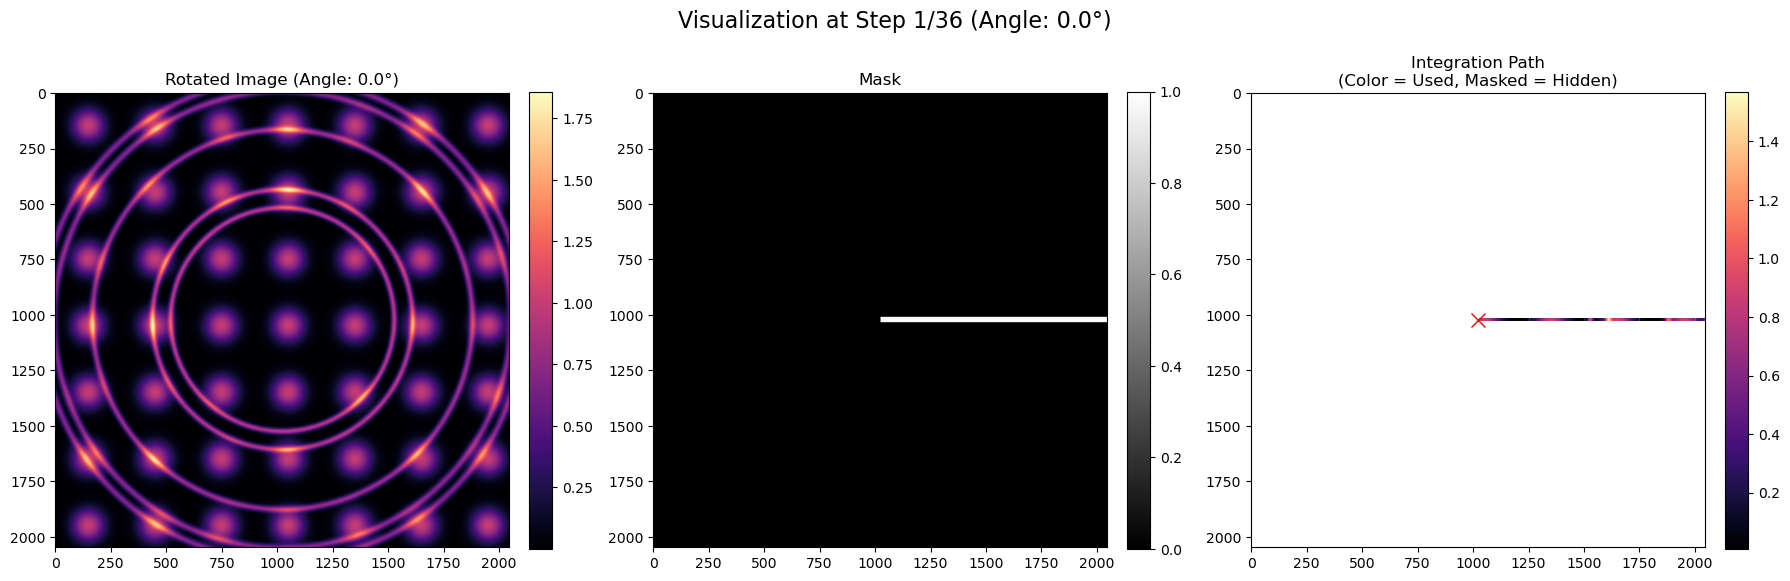

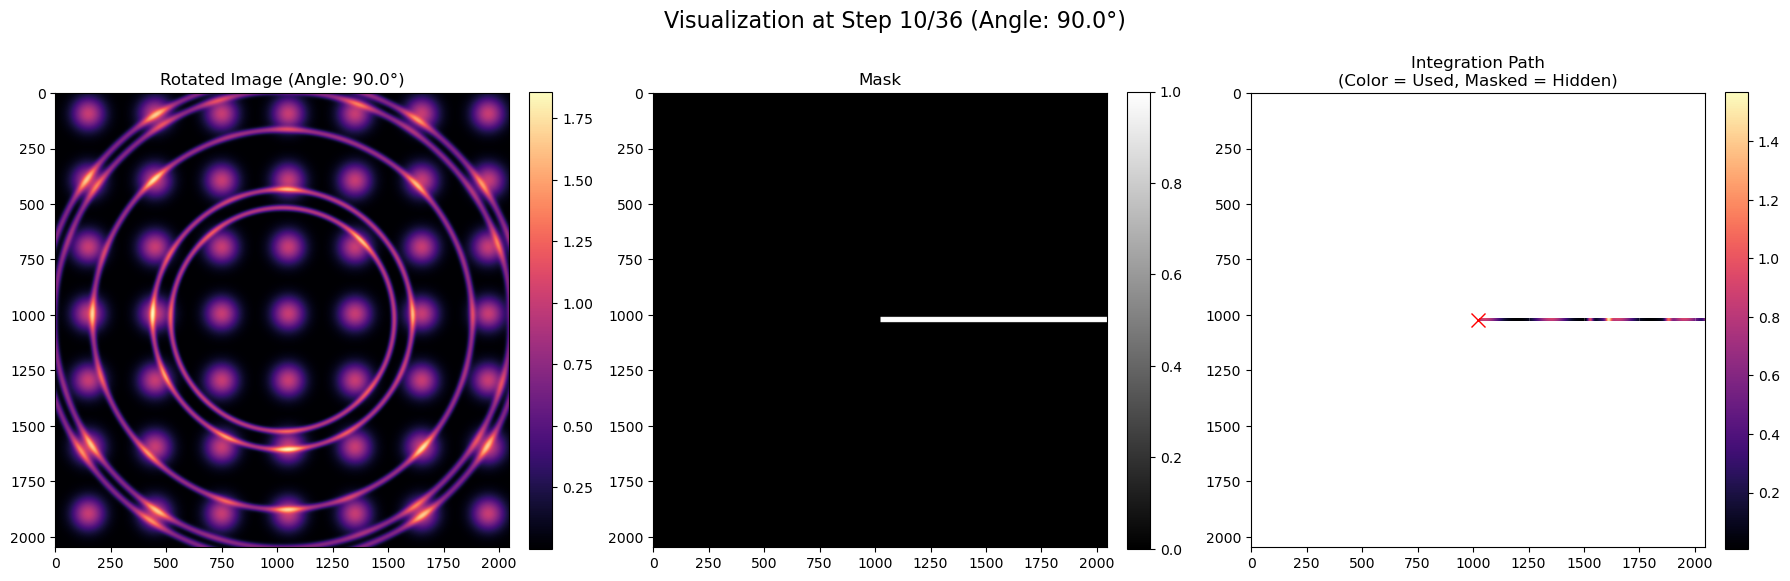

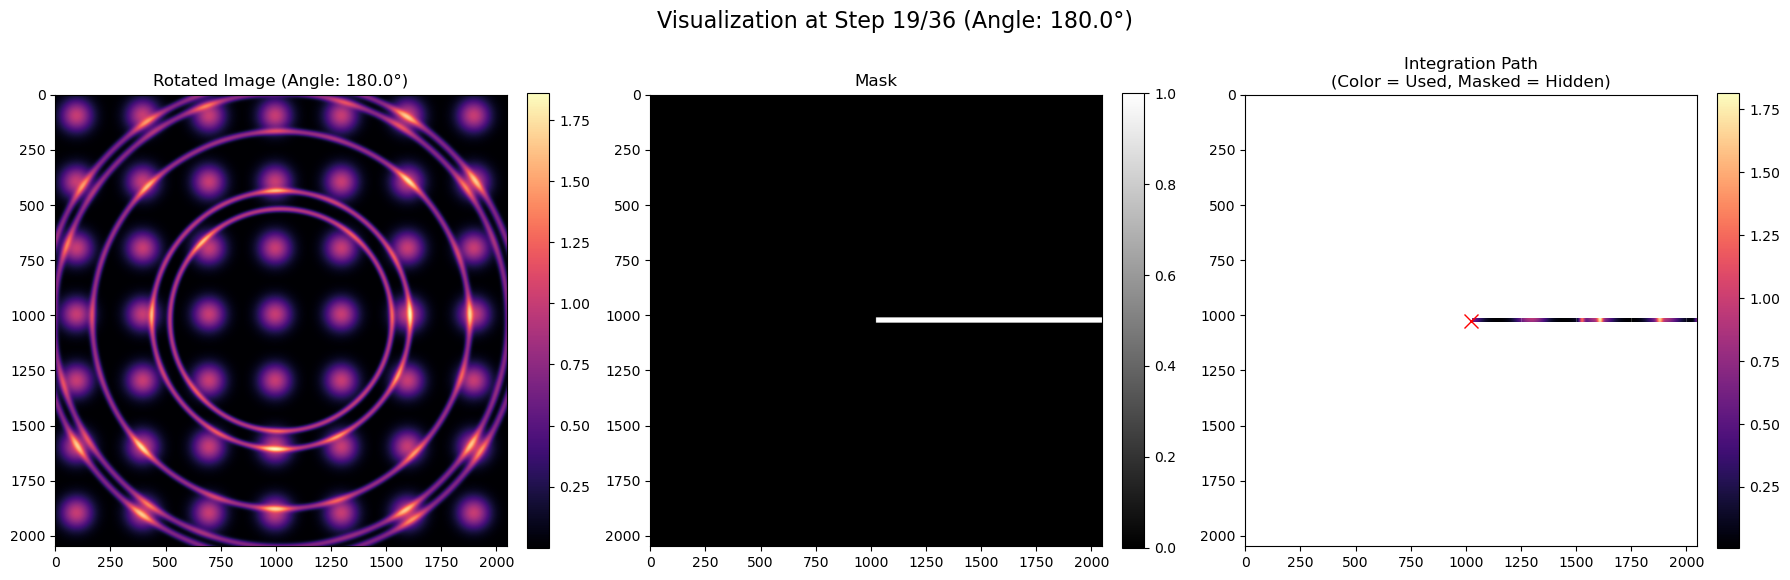

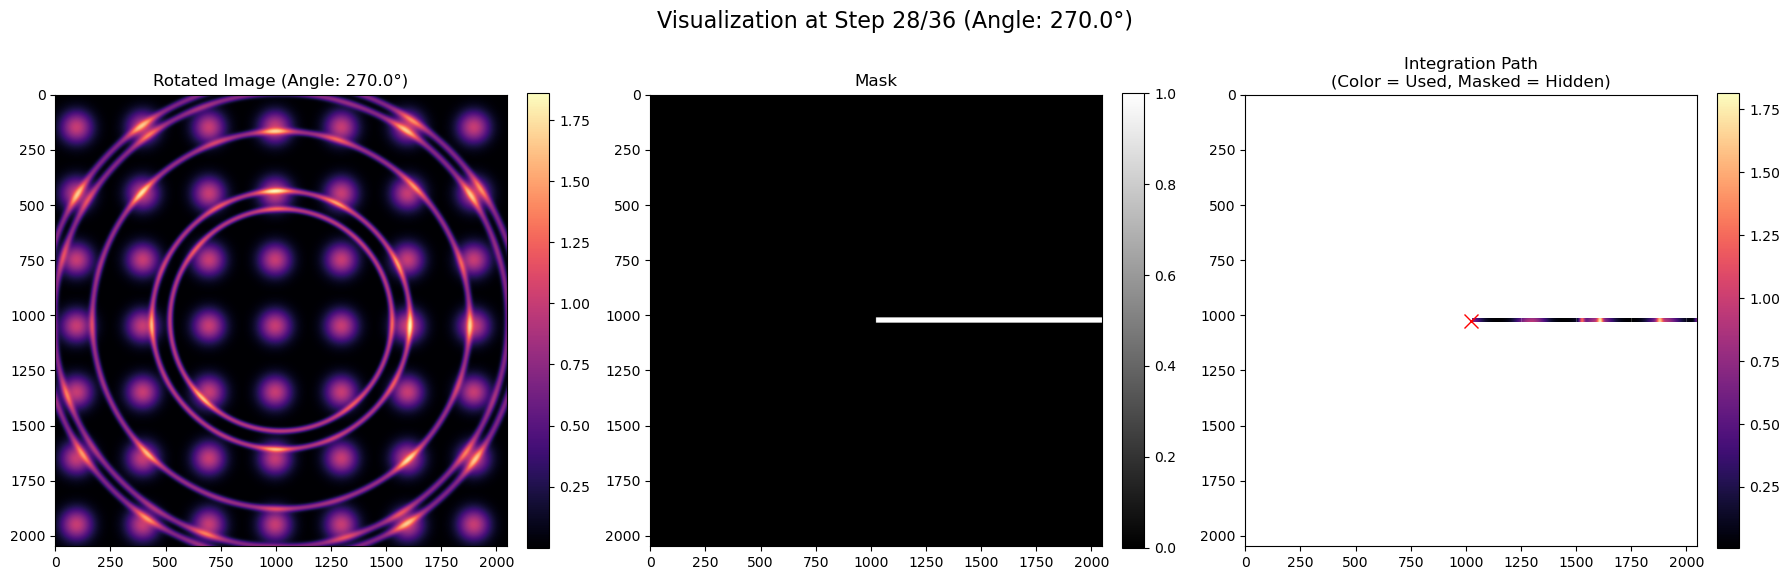

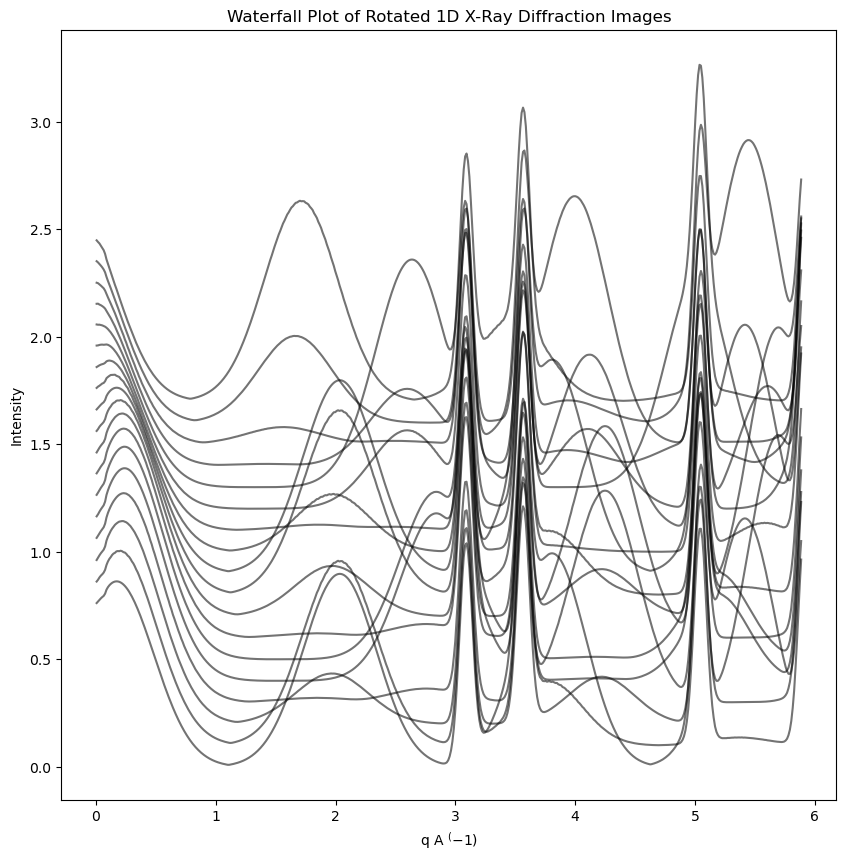

In [4]:
q, composite_data = sim.rotate_and_integrate(combined, 10, .4, .5e-10, resolution = 500, mask = mask12)